## **** PIPELINE FRACTALDEER ****

In [1]:
import os
import sys
from pathlib import Path
import shutil
import fractalFunctions
import geopandas as gpd
import pandas as pd
import subprocess
from PIL import Image

inPath = "./demo_data/Bajo/deerYear_2016-2017/Bajo_deerYear_2016-2017.csv"
inCSVname = Path(inPath).stem
deerName=inCSVname.split("_")[0]
deerYear = '_'.join(name for name in  inCSVname.split("_")[1:])
outFolder = os.path.join(Path(inPath).absolute().parent, "OUT_"+deerName+"_"+deerYear)

currPath = Path(os.getcwd())
print(inPath)
print(inCSVname)
print(deerName)
print(deerYear)
print(outFolder)
try:
    os.mkdir(outFolder)
except FileExistsError:
    print("directory exists")


rscript_path = shutil.which("Rscript")

print(rscript_path)


./demo_data/Bajo/deerYear_2016-2017/Bajo_deerYear_2016-2017.csv
Bajo_deerYear_2016-2017
Bajo
deerYear_2016-2017
/home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017
directory exists
/home/luvil/anaconda3/envs/pipeline_fractalDeer_prd/bin/Rscript


### Plot the result of the MigrateR model applied to the red deer trajectory

run the R script

In [2]:

resultS0 = subprocess.run(
    [rscript_path,
    "./S0_plotMigrateR.R", 
    inPath, 
    outFolder,
    "TRUE"], 
capture_output=True,
text=True)
print(resultS0.stderr)

Le chargement a nécessité le package : MASS
Le chargement a nécessité le package : trajr
Le chargement a nécessité le package : ggplot2
Le chargement a nécessité le package : gdata

Attachement du package : ‘gdata’

L'objet suivant est masqué depuis ‘package:stats’:

    nobs

L'objet suivant est masqué depuis ‘package:utils’:

    object.size

L'objet suivant est masqué depuis ‘package:base’:

    startsWith

Le chargement a nécessité le package : tidyverse
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine()     masks gdata::combine()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks gdata::first()
✖ purrr::keep()        masks gdata::keep()
✖ dplyr::lag()         masks stats::l

get the .png output of the S0 script and display it in the notebook

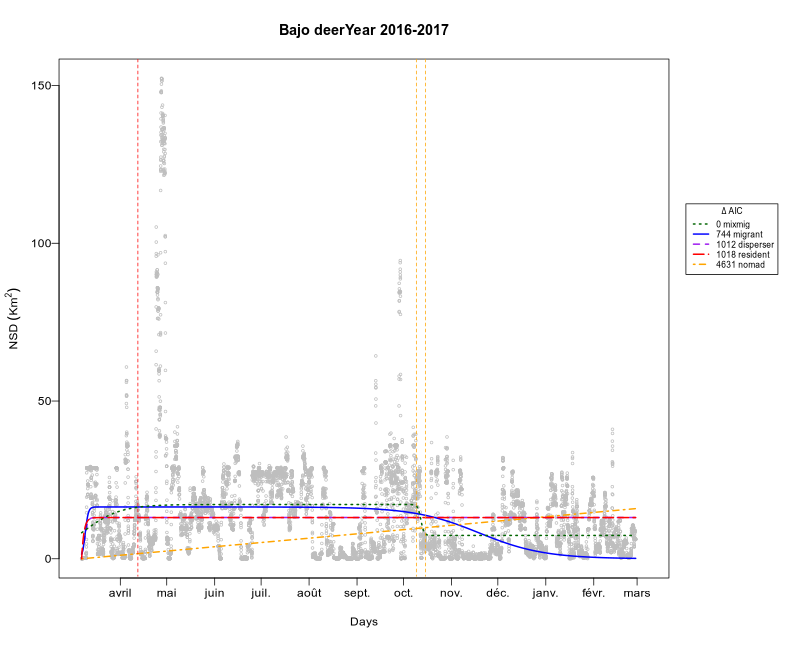

In [3]:
img = Image.open(os.path.join(outFolder, "MIGRATE_R PLOT " + ' '.join(inCSVname.split("_")[:])+".png") )
img

Use Trajr package in R To generate a Correlated Random Walk trajectory

In [4]:

resultS1 = subprocess.run(
    [rscript_path ,
    "./S1_generate_CRW.R", 
    inPath, 
    outFolder], 
capture_output=True,
text=True)
print(resultS1.stdout)

***** SIMULATE CRW TRAJECTORY ****

 deer Name -->  Bajo , deer Year -->  deerYear_2016-2017 
[1] "mean step length of the whole trajectory : "
[1] 37.36812
[1] "standard deviation step length of the whole trajectory : "
[1] 215.4514
--> CRW trajectory successfuly generated in 
 /home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Simulated_CRW_Bajo_deerYear_2016-2017.csv 



### if you want you can display the "simulated" trajectory by running the cell below

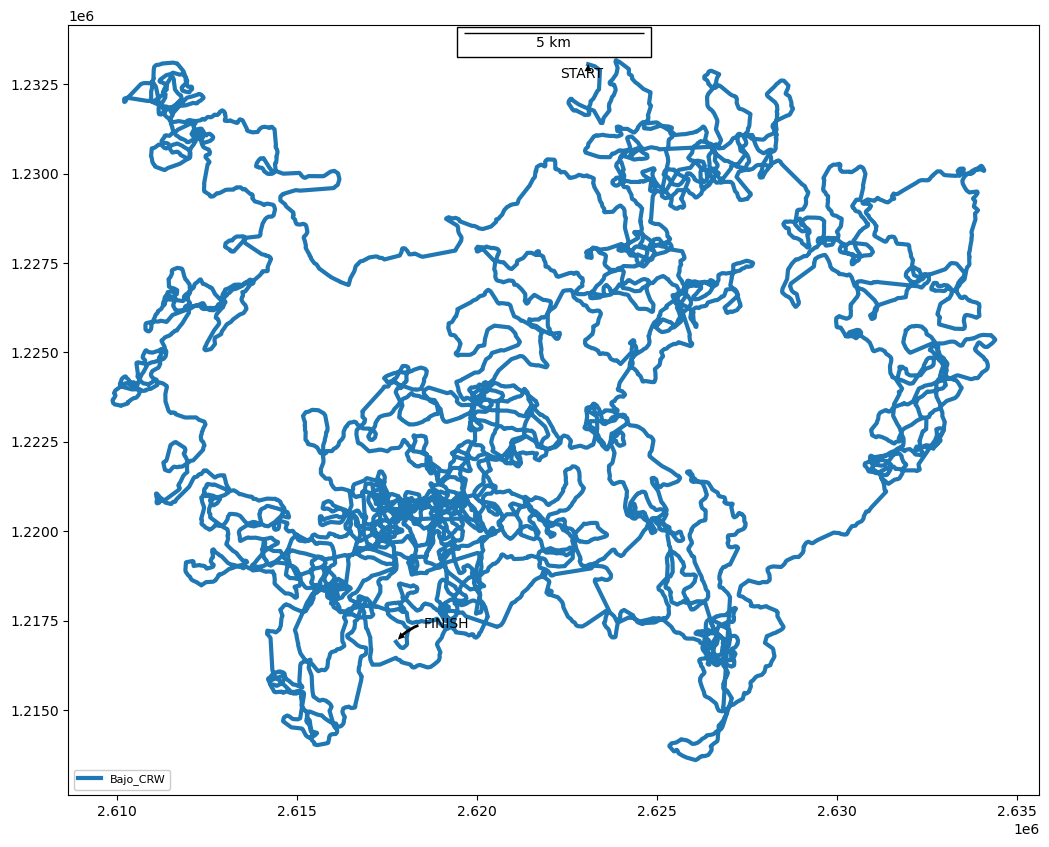

In [5]:

GPSdata = pd.read_csv(os.path.join(outFolder, '_'.join(str for str in ["Simulated_CRW", deerName, deerYear]))+'.csv')

gpd_sim = gpd.GeoDataFrame(GPSdata, 
geometry = gpd.GeoSeries.from_wkt(GPSdata["geometry"]))
fractalFunctions.showTrajectoryOnMap(gpd_sim, groupBy= "prenom")

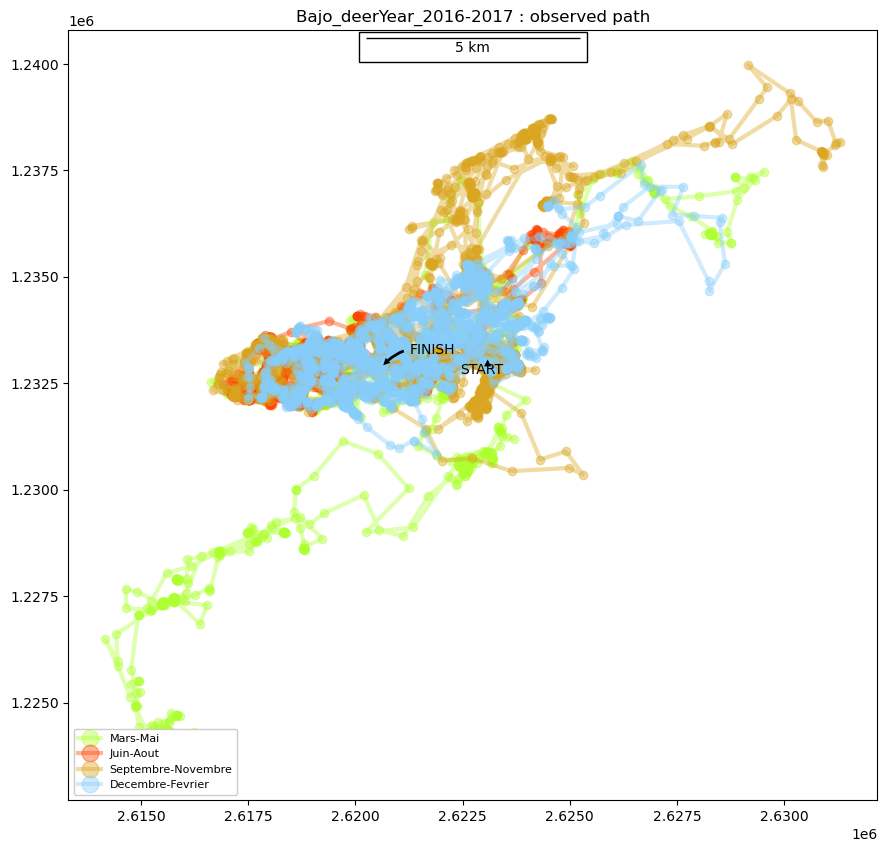

In [6]:
import fractalFunctions
import geopandas as gpd
import pandas as pd

GPSdata = pd.read_csv(inPath)

gpd_obs = gpd.GeoDataFrame(pd.read_csv(inPath), geometry = gpd.GeoSeries.from_wkt(GPSdata["geometry"]))
fractalFunctions.showTrajectoryOnMap(gpd_obs, groupBy= "saison")

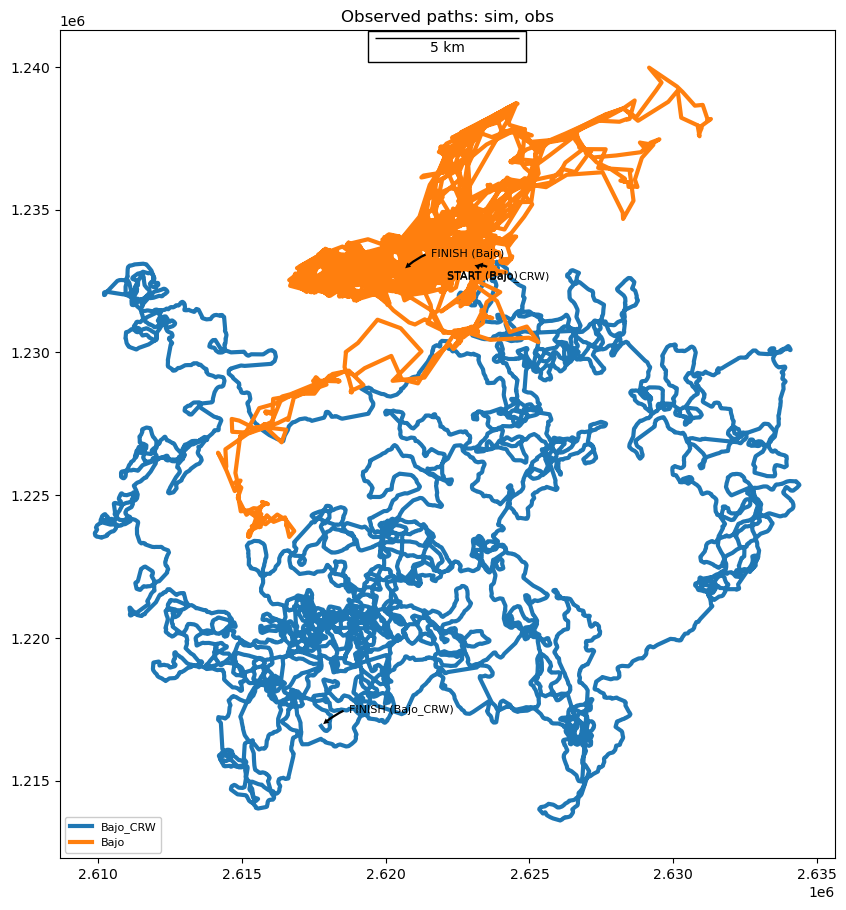

In [7]:
fractalFunctions.showMultipleTrajectoriesOnMap([gpd_sim,gpd_obs], groupBy= "prenom", plotNames=["sim", "obs"])

### Le script S2 calcule la valeur de fractalité selon Nams (2003) sur une série de divider dont la longueur est choisie suivant une progression géométrique entre 100m et le tiers de la distance maximale entre deux points de la trajectoire observée

In [8]:
import sys
sys.argv = ["S2_compute_Fractal_observed_and_simulated_trajectory.py", inPath, outFolder]

with open("./S2_compute_Fractal_observed_and_simulated_trajectory.py") as f:
    exec(f.read())


######### **** compute Fractal on observed and simulated trajectory ********* ########
 deer : Bajo -- deerYear : deerYear_2016-2017
 output directory : /home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017
run 15 complete
run 16 complete
run 14 complete
run 13 complete
run 12 complete
run 11 complete
run 9 complete
run 8 complete
run 10 complete
run 7 complete
run 6 complete
run 4 complete
run 5 complete
run 3 complete
run 2 complete
run 1 complete
run 25 complete
run 29 complete
run 28 complete
run 21 complete
run 20 complete
run 22 complete
run 27 complete
run 26 complete
run 24 complete
run 19 complete
run 23 complete
run 18 complete
run 17 complete
run 31 complete
run 30 complete
run 32 complete
run 45 complete
run 47 complete
run 48 complete
run 46 complete
run 43 complete
run 42 complete
run 44 complete
run 41 complete
run 40 complete
run 39 complete
run 38 complete
run 36 complete
run 35 complete
run 37 complete
run

le script S2 produit la courbe de valeur fractale en fonction du divider length pour la trajectoire simulée et observée

### le script S3 calcule le Z-score entre la trajectoire observée et la trajectoire simulée pour chaque longueur de divider.

In [9]:

resultS3 = subprocess.run(
    [rscript_path ,
    "./S3_get_Zscores_CRW.R", 
    outFolder], 
capture_output=True,
text=True)
print(resultS3.stdout)

[1] " ****** Z-SCORES COMPUTED *****"
[1] "/home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Bajo_deerYear_2016-2017_autocorrelation_obs_vs_crw.tiff"



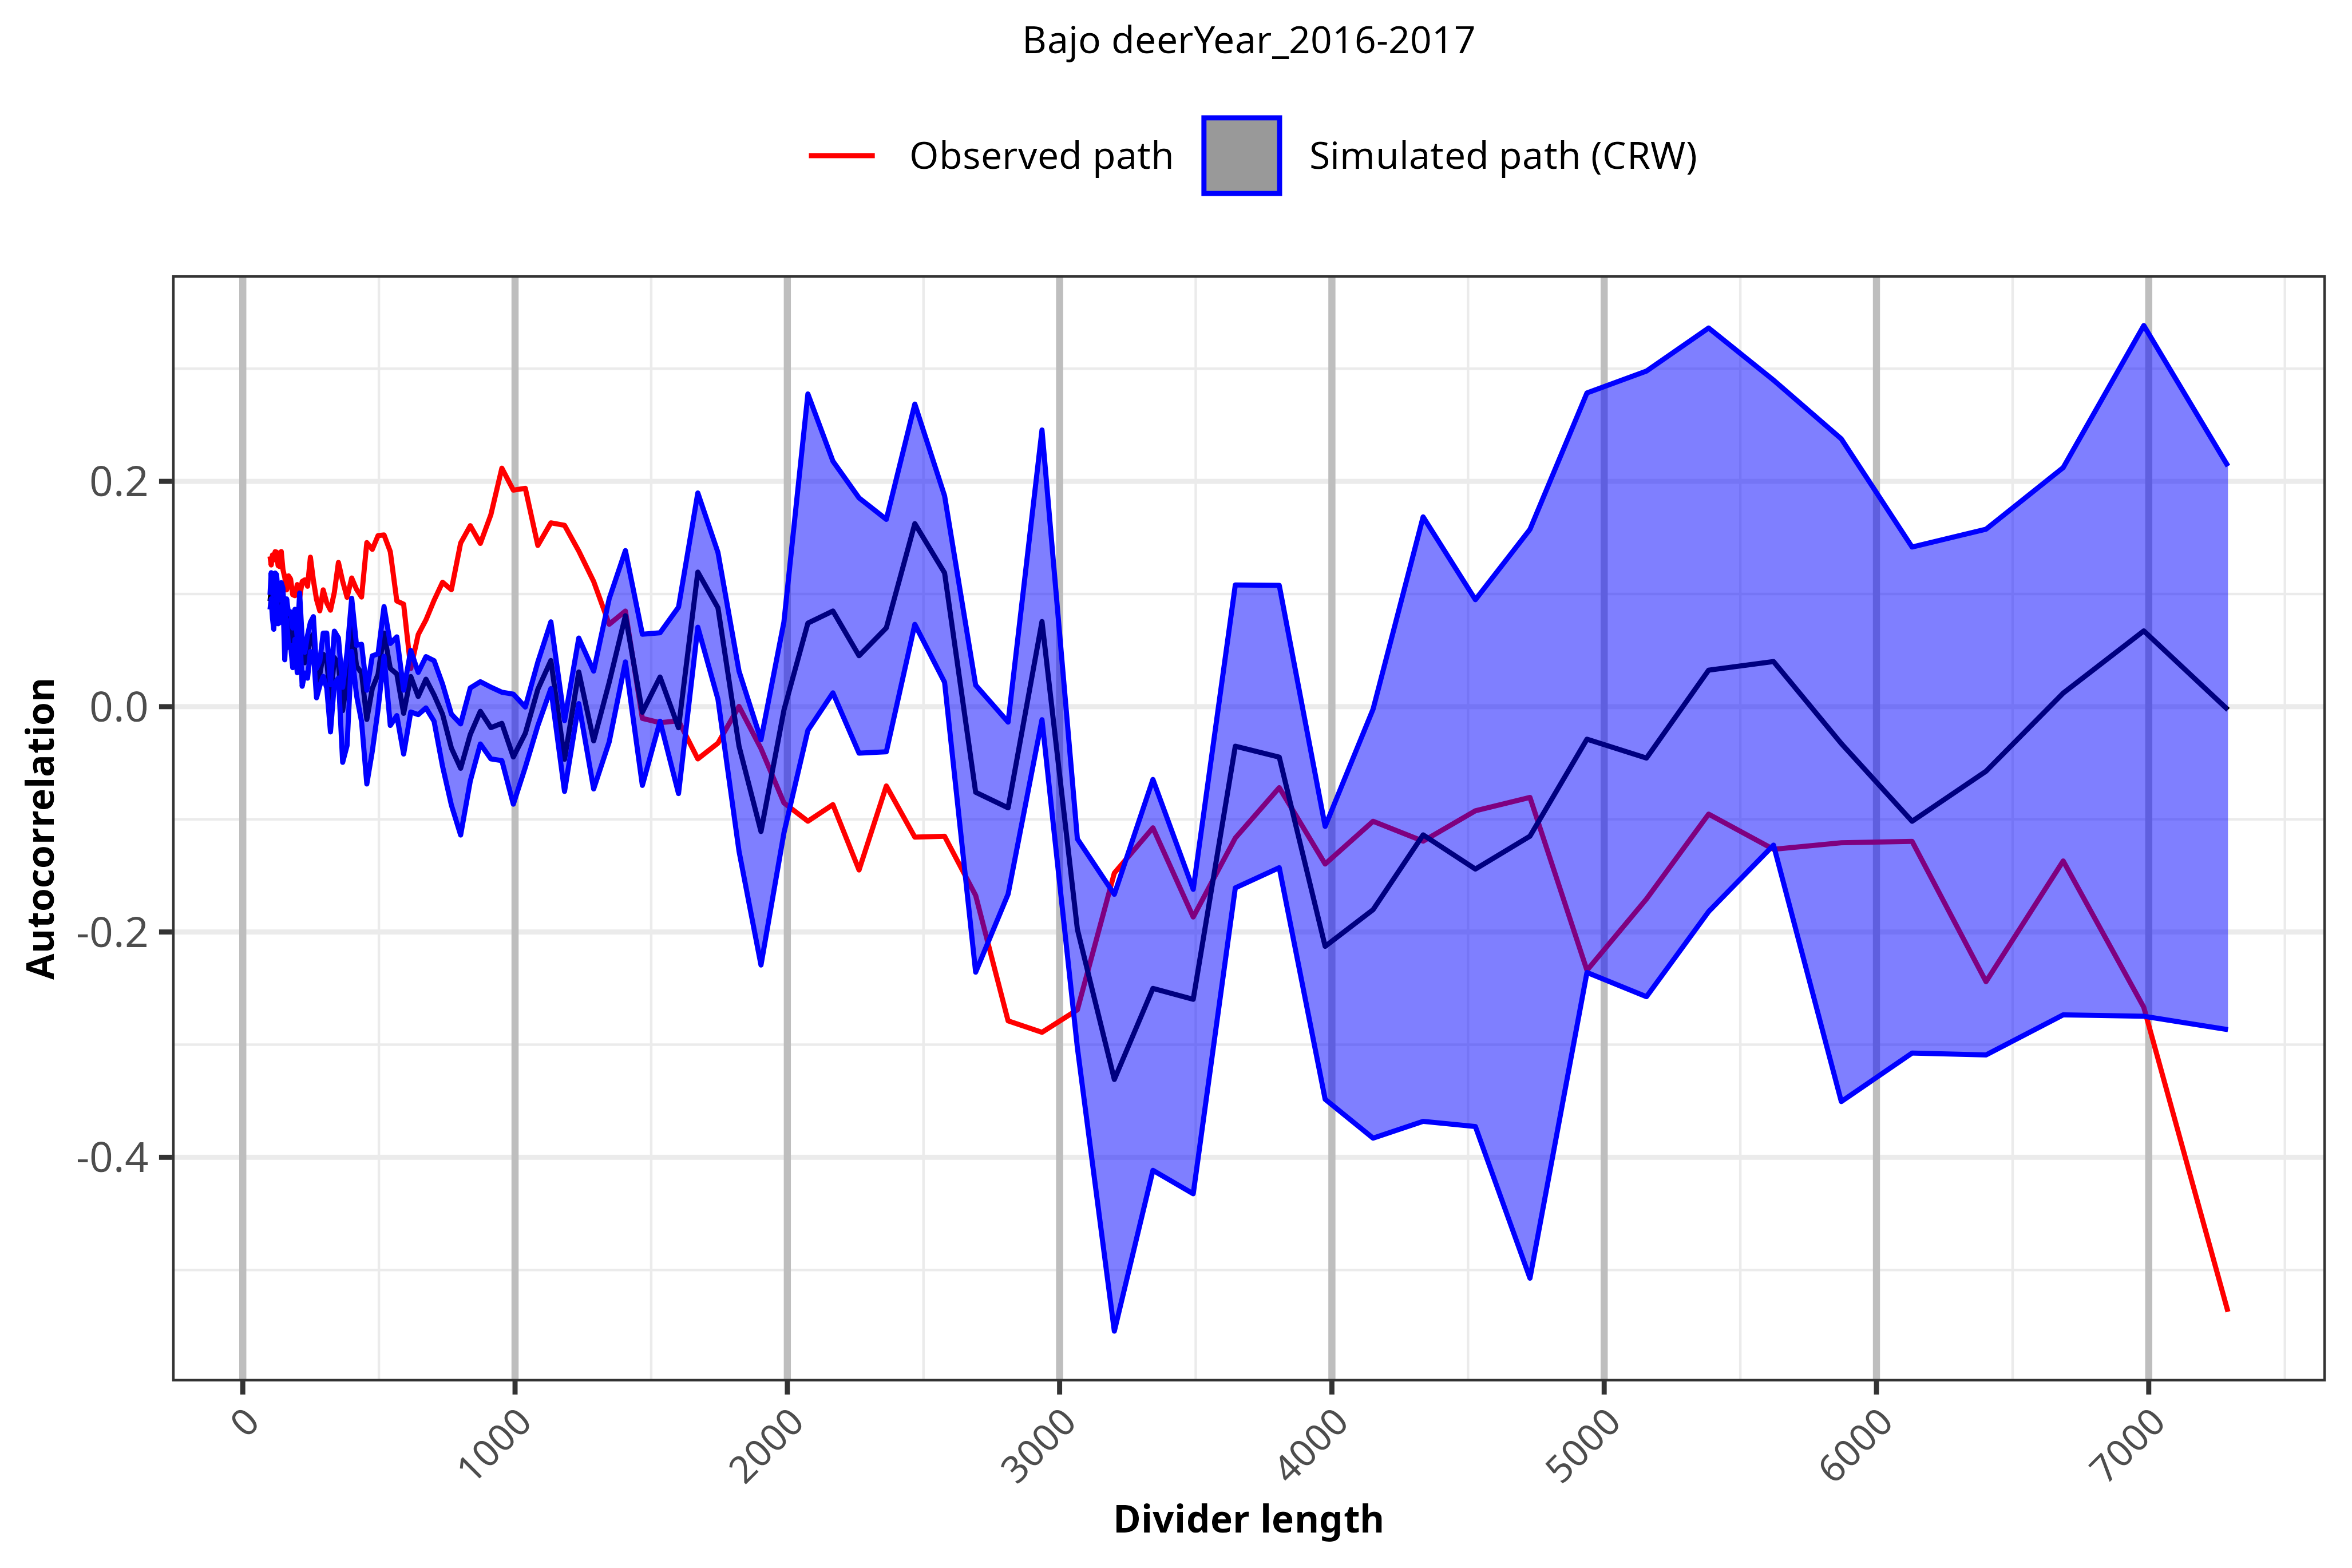

In [10]:
from PIL import Image
img = Image.open(os.path.join(outFolder, '_'.join(str for str in [deerName, deerYear, 'autocorrelation_obs_vs_crw.tiff']) ))
img

###  les divider length possédant les plus hautes valeurs de z-scores sont considérées comme des modèles candidats pour la segmentation de la trajectoire en deux comportement. Elle sont stockées dans le fichier "candidate_stepSizes_from_upConf.csv"

In [2]:
candidateDL = os.path.join(outFolder, '_'.join(str for str in [deerName, deerYear, 'candidate_stepSizes_from_upConf.csv']) )

candidateDL_df = pd.read_csv(candidateDL)

candidateDL_df.sort_values(by="zscore",ascending=False).head(10)

,prenom,deerYear,stepSize,obs,zscore
25,Bajo,deerYear_2016-2017,951.554412,0.211705,0.198881
27,Bajo,deerYear_2016-2017,1037.685361,0.193834,0.194170
26,Bajo,deerYear_2016-2017,993.687116,0.192206,0.181094
30,Bajo,deerYear_2016-2017,1181.717818,0.160981,0.173404
21,Bajo,deerYear_2016-2017,800.146486,0.145223,0.160550
24,Bajo,deerYear_2016-2017,911.208151,0.170414,0.153097
22,Bajo,deerYear_2016-2017,835.575184,0.160661,0.144050
9,Bajo,deerYear_2016-2017,455.576271,0.145652,0.131076
23,Bajo,deerYear_2016-2017,872.572587,0.144880,0.122729
20,Bajo,deerYear_2016-2017,766.219977,0.103804,0.110434


### le script S4 tente d'attribuer des classes de comportement ("mouvements dirigés" ou "mouvements tortueux") sur les portions de segments de chaque longueur de divider préalablement sélectionnées. On utilise les variation de turning angle entre deux segments sur toute la trajectoire en appliquant l'algorithme "time-series-k-means" pour détecter les breakpoints. 

In [3]:
import S4_get_behaviour_vector_from_list as S4
S4.run(inPath, candidateDL,False)

**** RUN S4_get_behaviour_vector_from_list.py ****
candidate step list : /home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Bajo_deerYear_2016-2017_candidate_stepSizes_from_upConf.csv
input file : ./demo_data/Bajo/deerYear_2016-2017/Bajo_deerYear_2016-2017.csv
 output directory : /home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017
overwriting file ? False
==> computing selected step size : 308.472756043924...
          
==> computing selected step size : 336.394492048807...
          ==> computing selected step size : 322.131240459989...
          ==> computing selected step size : 383.086608034152...
          ==> computing selected step size : 351.289288549553...
          ==> computing selected step size : 366.843593359866...
          ==> computing selected step size : 436.259667515067...
          ==> computing selected step size : 455.576270856412...
  

### le script S5 estime la qualité de l'attribution des deux classes en calculant divers métriques sur les portions de segments. Trois métriques ont été utilisées : le Net-square dispalcement moyen divisé par le nombre de points observés compris dans la portion de segment("ratoi_meanNSD"), la somme des NSD ("ratio_cumulativeNSD") ainsi que le NSD maximum ("ratio_maxNSD") de ces mêmes portions

In [24]:

resultS5 = subprocess.run(
    [rscript_path ,
    "./S5_choose_best_stepSize_V3.R", 
    outFolder,
    candidateDL], 
capture_output=True,
text=True)
print(resultS5.stdout)


********************************************

****** S5 : CHOOSE_BEST_STEPSIZES.R ********

********************************************
- input file :  /home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Bajo_deerYear_2016-2017_candidate_stepSizes_from_upConf.csv 

*******  Bajo  ::  deerYear_2016-2017  -->  308   ******

*******  Bajo  ::  deerYear_2016-2017  -->  322   ******

*******  Bajo  ::  deerYear_2016-2017  -->  336   ******

*******  Bajo  ::  deerYear_2016-2017  -->  351   ******

*******  Bajo  ::  deerYear_2016-2017  -->  367   ******

*******  Bajo  ::  deerYear_2016-2017  -->  383   ******

*******  Bajo  ::  deerYear_2016-2017  -->  400   ******

*******  Bajo  ::  deerYear_2016-2017  -->  418   ******

*******  Bajo  ::  deerYear_2016-2017  -->  436   ******

*******  Bajo  ::  deerYear_2016-2017  -->  456   ******

*******  Bajo  ::  deerYear_2016-2017  -->  476   ******

*******  Bajo  ::  deerYear_20

### la valeur de chi-carré des différentes métriques entre les deux classes sont calculées et stockées dans les fichiers "results_chisq_[métrique].csv"

In [5]:
meanNSD = os.path.join(outFolder, '_'.join(str for str in ["results_Chisq_meanNSD",deerName, deerYear, 'from_upConf.csv']) )

meanNSD_df = pd.read_csv(meanNSD)

meanNSD_df.sort_values(by="zscore",ascending=False).head(10)

,prenom,deerYear,stepSize,chisq.raw,chisq.raw.pval,fullPath,parameter,zscore
0,Bajo,deerYear_2016-2017,952,35.317122,2.801582e-09,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.198881
1,Bajo,deerYear_2016-2017,1038,36.483522,1.539623e-09,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.194170
2,Bajo,deerYear_2016-2017,994,45.714513,1.368050e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.181094
3,Bajo,deerYear_2016-2017,1182,27.106313,1.925681e-07,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.173404
4,Bajo,deerYear_2016-2017,800,43.410685,4.437580e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.160550
5,Bajo,deerYear_2016-2017,911,44.279374,2.847000e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.153097
6,Bajo,deerYear_2016-2017,836,60.123765,8.900000e-15,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.144050
7,Bajo,deerYear_2016-2017,456,64.494073,9.000000e-16,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.131076
8,Bajo,deerYear_2016-2017,873,45.887004,1.252740e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.122729
9,Bajo,deerYear_2016-2017,766,32.910454,9.650294e-09,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.110434


In [6]:
import ipywidgets as ipw
from IPython.display import display
def plotBehaviourNSD(stepSizeSelection, metric):
    segmentationFile = meanNSD_df.loc[meanNSD_df["stepSize"]==stepSizeSelection, "fullPath"].to_list()[0]
    results = subprocess.call(
        [rscript_path,
        "./S6_3_refine_classification_interactive.R", 
        segmentationFile,
        metric]
        
        )  
    img = Image.open(os.path.join(outFolder, "tmp_S6_3.png" ))
    display(img)
    
###################### GUI interactive function #####################################

x = meanNSD_df.sort_values(by="stepSize",ascending=True).loc[10:1, "stepSize"].to_list()

style = {'description_width': 'initial'}
layout={"width":"800px"}
menu=ipw.interactive(
     plotBehaviourNSD,{"manual":True},
stepSizeSelection = ipw.SelectionSlider(options=x, value=x[0], description="choose divider size where to compute NSD metrics ",style=style,layout=ipw.Layout(width="800px", height="40px")),
metric=ipw.Dropdown(options=["ratio_meanNSD","ratio_endNSD","ratio_cumulativeNSD"], 
                                   value="ratio_meanNSD", description="metric to use", disabled=False),

)

box=ipw.VBox(
[ ipw.HBox(menu.children) ] ,
layout=ipw.Layout(width='100px', display="flex"))

display(menu)
#######################################################################################

interactive(children=(SelectionSlider(description='choose divider size where to compute NSD metrics ', layout=…